# Spatiotemporal Dynamics of 3D Drosophila Embryos and Organs

In this tutorial, we demonstrate how to perform spatiotemporal dynamics reconstruction and analysis of regulatory relationships using the 3D Drosophila embryos and organs dataset, as presented in our stVCR study. This notebook reproduces the analyses reported in Figure 5 of the paper.

## Load relevant packages

In [1]:
import scanpy as sc
import numpy as np
import scipy.sparse as sp
from scipy.sparse import csr_matrix

In [2]:
import sys
from pathlib import Path

# Obtain the absolute path of src
src_path = Path("../src").resolve()

# Add src to sys.path
if str(src_path) not in sys.path:
    sys.path.append(str(src_path))

In [3]:
# load stvcr
import stvcr

2026-03-13 12:10:24.700683: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-13 12:10:24.748036: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-13 12:10:24.761599: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-13 12:10:25.527822: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
/home/pqw/anaconda3/envs/spatial/lib/python3.10/site-packages/numba/np/ufunc/dufunc.py:343: NumbaWarning: Compilation requested for previously compiled argument types ((uint32,)). This has no effect and perhaps indicates a bug in the calling

In [4]:
# Load the autoreload extension to automatically reload modules before executing code
%load_ext autoreload

# Automatically reload all imported modules before each execution
%autoreload 2

# Use interactive matplotlib plots in Jupyter notebooks
%matplotlib notebook

# Use static matplotlib plots embedded directly in the notebook
%matplotlib inline  

In [5]:
# Force PyOpenGL to use OSMesa (Off-Screen Mesa) backend
# This allows 3D rendering in "headless" environments (servers/Docker) without a display
import os
os.environ["PYOPENGL_PLATFORM"] = "osmesa"

In [6]:
import random
import torch

# Set random seed for reproducibility
seed = 19491001
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

## Load Data

The processed 3D Drosophila embryo datasets can be downloaded from the [Spateo](https://github.com/aristoteleo/spateo-release) package (https://www.dropbox.com/s/bvstb3en5kc6wui/E7-9h_cellbin_tdr_v2.h5ad?dl=1 and https://www.dropbox.com/s/q02sx6acvcqaf35/E9-10h_cellbin_tdr_v2.h5ad?dl=1).

In [7]:
adata = sc.read_h5ad('../datasets/Drosophila3D_after_pp.h5ad')
adata.X = csr_matrix(adata.X)
adata.obsm['spatial'] = adata.obsm['3d_align_spatial'].copy()
# adata = adata[np.random.choice(adata.shape[0], 5000, replace=False), :].copy()

Set the model storage path

In [8]:
ae_model_save_path='./save_model/Drosophila3D/ae_Drosophila3D.pth' # Path to save the autoencoder model
model_path = './save_model/Drosophila3D/stvr_model_Drosophila3D.pth' # Path to save the stVCR model
rigid_transformation_path='./save_model/Drosophila3D/rigid_model_Drosophila3D.pth' # Path to save the rigid transformation model
st_classifier_save_path = './save_model/Drosophila3D/anno_model_Drosophila3D.pth' # Path to save the classifier model

## Preprocess data

The data preprocessing procedure of stvcr consists of three steps: 
1. Use scanpy to filter cells and genes and select highly variable genes; 
2. Train autoencoders to reduce the dimension of gene expression; 
3. Initially align the spatial coordinates.

Since the data we are loading has already undergone preprocessing using Scanpy, we set use_pp_with_scanpy=False.

In [9]:
# stvcr.pp.pp_stvcr(adata=adata, 
#                   ae_model_save_path='./save_model/ae_Drosophila3D.pth', 
#                   n_epochs = 100, 
#                   use_pp_with_scanpy=False,)

In [10]:
stvcr.pp.pp_stvcr(adata=adata, 
                  use_pp_with_scanpy = False,
                  ae_model_save_path=ae_model_save_path, 
                  z_dims = 10,
                  use_initial_alignment=True,
                  spatial_key = 'spatial',
                  time_key = 'time',
                  n_epochs=100,
                  )

Start training autoencoder...
**Epoch 0**  
Train Loss: `0.240751`  
Valid Loss: `0.019387`
Autoencoder training finished.


/home/pqw/anaconda3/envs/spatial/lib/python3.10/site-packages/ot/lp/__init__.py:361: UserWarning:

numItermax reached before optimality. Try to increase numItermax.



AnnData object with n_obs × n_vars = 41493 × 2002
    obs: 'area', 'slices', 'nGenes', 'nCounts', 'pMito', 'nMito', 'pass_basic_filter', 'scc', 'auto_anno', 'anno_cell_type', 'anno_tissue', 'anno_germ_layer', 'actual_stage', 'Size_Factor', 'initial_cell_size', 'time', 'batch', 'n_genes', 'time_input'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'hvg', 'spatial_scale_factor'
    obsm: '3d_align_spatial', 'bbox', 'before_3d_align_spatial', 'spliced', 'unspliced', 'spatial', 'X_ae', 'X_gene_input', 'X_spatial_input'
    layers: 'counts_X', 'log1p_X', 'spliced', 'unspliced'

## stVCR training

Set the training hyperparameters

In [11]:
default_config = {'learning_rate' : 5e-4,
                  'learning_rate_rigid' : 5e-5,
                  'n_epochs' : 3001,
                  'num_samples' : 500,
                  'lambda_match' : 1e3,
                  'lambda_SSP' : 1e3,
                  'alpha_exp' : 0.01,
                  'alpha_gro' : 0.0002,
                  'kappa_exp' : 0.5,
                  'kappa_gro' : 0.1,
                  'spa_neighbor' : 30,
                  'exp_neighbor' : 10}

We added biological priors central nervous system (CNS) transition to CNS, midgut transition to midgut, and amnioserosa transition to amnioserosa. Additionally, we added the spatial-structure-preserving priors for CNS and midgut.

In [12]:
cell_type_prior = [[{'CNS'}, {'CNS'}], [{'midgut'}, {'midgut'}], [{'amnioserosa'}, {'amnioserosa'}]]
cell_type_key = 'anno_tissue'
SSP_prior = [True, True, False]

In [13]:
stvcr.tr.train_stvcr(adata=adata, 
                     model_path = model_path, 
                     rigid_transformation_path=rigid_transformation_path,
                     config=default_config, 
                     cell_type_prior=cell_type_prior, 
                     cell_type_key=cell_type_key,
                     SSP_prior=SSP_prior,)

  0%|          | 0/3001 [00:00<?, ?it/s]/home/pqw/project/stVCR/stVCR/src/stvcr/training/train.py:1238: UserWarning:

To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).

/home/pqw/project/stVCR/stVCR/src/stvcr/training/train.py:1242: UserWarning:

To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).

/home/pqw/anaconda3/envs/spatial/lib/python3.10/site-packages/torchdiffeq/_impl/misc.py:15: UserWarning:

Dopri5Solver: Unexpected arguments {'step_size': 0.1}

/home/pqw/project/stVCR/stVCR/src/stvcr/training/model.py:84: UserWarning:

To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).

/home/pqw/proje

----------
iter 0
loss: tensor([971.3691], device='cuda:0', grad_fn=<AddBackward0>)
loss_wfr: tensor([0.0228], device='cuda:0', grad_fn=<SubBackward0>)
loss_ssp: tensor([2.3048e-09], device='cuda:0', grad_fn=<SubBackward0>)


  7%|▋         | 201/3001 [20:07<5:53:57,  7.58s/it]

----------
iter 200
loss: tensor([425.3506], device='cuda:0', grad_fn=<AddBackward0>)
loss_wfr: tensor([0.0817], device='cuda:0', grad_fn=<SubBackward0>)
loss_ssp: tensor([5.0590e-05], device='cuda:0', grad_fn=<SubBackward0>)


 13%|█▎        | 401/3001 [46:17<5:49:36,  8.07s/it]

...

----------
iter 2600
loss: tensor([162.1096], device='cuda:0', grad_fn=<AddBackward0>)
loss_wfr: tensor([0.5792], device='cuda:0', grad_fn=<SubBackward0>)
loss_ssp: tensor([0.0014], device='cuda:0', grad_fn=<SubBackward0>)


 93%|█████████▎| 2801/3001 [11:14:49<1:06:23, 19.92s/it]

----------
iter 2800
loss: tensor([158.8560], device='cuda:0', grad_fn=<AddBackward0>)
loss_wfr: tensor([0.5273], device='cuda:0', grad_fn=<SubBackward0>)
loss_ssp: tensor([0.0020], device='cuda:0', grad_fn=<SubBackward0>)


100%|██████████| 3001/3001 [12:24:48<00:00, 14.89s/it]  

----------
iter 3000
loss: tensor([156.2118], device='cuda:0', grad_fn=<AddBackward0>)
loss_wfr: tensor([0.5281], device='cuda:0', grad_fn=<SubBackward0>)
loss_ssp: tensor([0.0031], device='cuda:0', grad_fn=<SubBackward0>)


Train the classifier using the aligned data for annotating unobserved time data

In [14]:
label_to_cell_type_map = stvcr.dsm.create_spatiotemporal_classifier(adata, 
                              st_classifier_save_path = st_classifier_save_path,
                              annotation_key='anno_tissue',)

Start training spatiotemporal classifier...


Early stopping in current iteration!
Spatiotemporal classifier training finished.


In [15]:
label_to_cell_type_map

{0: 'CNS',
 1: 'amnioserosa',
 2: 'epidermis',
 3: 'hemolymph',
 4: 'midgut',
 5: 'muscle',
 6: 'salivary gland',
 7: 'trachea',
 8: 'yolk'}

In [16]:
cell_type_color_map = {
    "CNS": "#5A2686",
    "midgut": "#DC143C",
    "amnioserosa": "#FFDD00",
    "salivary gland": "#FFA500",
    "epidermis": "#ADD8E6",
    "muscle": "#1AAB27",
    "trachea": "#7F90F0",
    "hemolymph": "#CD5C5C",
    "yolk": "#8B0000",
}

## Analyzing the developmental spatiotemporal dynamics of Drosophila embryos and organs

/home/pqw/project/stVCR/stVCR/src/stvcr/downstream/utils.py:49: UserWarning:

To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).



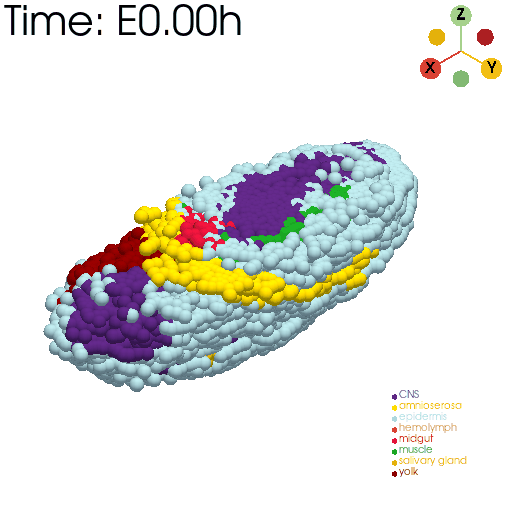

In [17]:
# embryo-level
stvcr.dsm.generate_video(adata, 
                         model_path=model_path, 
                         st_classifier_path=st_classifier_save_path, 
                         label_to_cell_type_map=label_to_cell_type_map, 
                         cell_type_color_map = cell_type_color_map,
                         save_path='./save_results/stvcr_Drosophila3D.gif',
                         show_or_save='save_and_show',
                         end_time=1.5,)

/home/pqw/project/stVCR/stVCR/src/stvcr/training/model.py:124: UserWarning:

To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).

/home/pqw/project/stVCR/stVCR/src/stvcr/downstream/utils.py:49: UserWarning:

To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).

/home/pqw/project/stVCR/stVCR/src/stvcr/training/model.py:84: UserWarning:

To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).



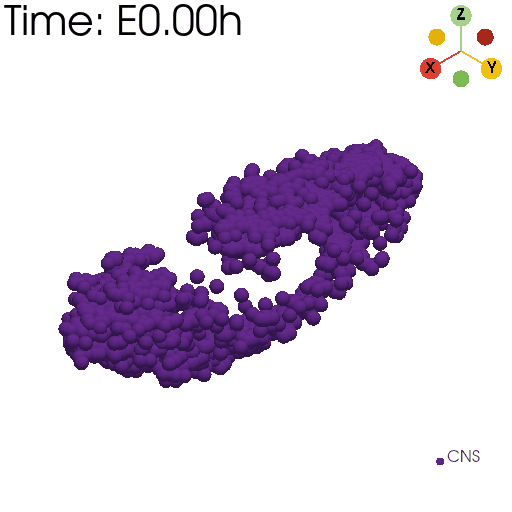

In [18]:
# organ-level (central nervous system)
stvcr.dsm.generate_video(adata[adata.obs['anno_tissue'] == 'CNS'], 
                         model_path=model_path, 
                         st_classifier_path=st_classifier_save_path, 
                         label_to_cell_type_map=label_to_cell_type_map, 
                         cell_type_color_map = cell_type_color_map,
                         save_path='./save_results/stvcr_Drosophila3D_CNS.gif',
                         show_or_save='save_and_show',
                         end_time=1.5,
                         init_cell_type='CNS',
                         fix_cell_type=True)